# Stock Price Movement Prediction

This notebook demonstrates a machine learning workflow to predict stock price movements (Up vs. Down). The process includes:

*   **Data Preparation:** Cleaning and feature selection of technical stock indicators.
*   **Baseline Modeling:** Establishing initial performance using Random Forest.
*   **Optimization:** Tuning hyperparameters with Time-Series Cross-Validation to prevent look-ahead bias.
*   **Advanced Boosting:** Implementing and evaluating XGBoost for superior predictive accuracy.
*   **Final Evaluation:** Assessing model performance via ROC curves and feature importance analysis.

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#modeling libraries
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

import joblib

In [2]:
# Rechecking the dataste
df = pd.read_csv("NSE_clean_data_with_features.csv")
df["Date"] = pd.to_datetime(df["Date"])
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (7233, 36)


,Date,Code,Name,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,...,Vol_20,Price_to_High,Price_to_Low,Daily_Return,Day_of_Week,Month,Quarter,Volume_MA_5,Volume_Ratio,Target
0,2026-01-02,ABSA,ABSA Bank Kenya Plc,15.0,33.0,24.3,25.45,24.85,24.70,0.15,...,NaN,0.753030,1.656667,NaN,4,1,1,140294.000000,1.000000,25.45
1,2026-01-05,ABSA,ABSA Bank Kenya Plc,15.0,33.0,24.0,26.00,25.45,24.85,0.60,...,0.424264,0.771212,1.696667,0.024145,0,1,1,196878.500000,1.287408,26.05
2,2026-01-06,ABSA,ABSA Bank Kenya Plc,15.0,33.0,25.0,26.50,26.05,25.45,0.60,...,0.600000,0.789394,1.736667,0.023576,1,1,1,312606.333333,1.740406,25.65
3,2026-01-07,ABSA,ABSA Bank Kenya Plc,15.0,33.0,25.0,26.00,25.65,26.05,-0.40,...,0.500000,0.777273,1.710000,-0.015355,2,1,1,320765.250000,1.076307,25.50
4,2026-01-08,ABSA,ABSA Bank Kenya Plc,15.0,33.0,25.1,25.75,25.50,25.65,-0.15,...,0.433013,0.772727,1.700000,-0.005848,3,1,1,321286.600000,1.006491,25.55


In [3]:
# Checking info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7233 entries, 0 to 7232
Data columns (total 36 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            7233 non-null   datetime64[ns]
 1   Code            7233 non-null   object        
 2   Name            7233 non-null   object        
 3   12m Low         7233 non-null   float64       
 4   12m High        7233 non-null   float64       
 5   Day Low         7233 non-null   float64       
 6   Day High        7233 non-null   float64       
 7   Day Price       7233 non-null   float64       
 8   Previous        7233 non-null   float64       
 9   Change          7233 non-null   float64       
 10  Change%         7233 non-null   float64       
 11  Volume          7233 non-null   float64       
 12  Adjusted Price  7233 non-null   object        
 13  Sector          7233 non-null   object        
 14  Stock_code      7225 non-null   object        
 15  Stoc

In [4]:
# Checking the columns
print(df.columns.tolist())

['Date', 'Code', 'Name', '12m Low', '12m High', 'Day Low', 'Day High', 'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Adjusted Price', 'Sector', 'Stock_code', 'Stock_name', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'Lag_10', 'MA_5', 'Vol_5', 'MA_10', 'Vol_10', 'MA_20', 'Vol_20', 'Price_to_High', 'Price_to_Low', 'Daily_Return', 'Day_of_Week', 'Month', 'Quarter', 'Volume_MA_5', 'Volume_Ratio', 'Target']


In [5]:
# Checking dtype
print(df.dtypes)

Date              datetime64[ns]
Code                      object
Name                      object
12m Low                  float64
12m High                 float64
Day Low                  float64
Day High                 float64
Day Price                float64
Previous                 float64
Change                   float64
Change%                  float64
Volume                   float64
Adjusted Price            object
Sector                    object
Stock_code                object
Stock_name                object
Lag_1                    float64
Lag_2                    float64
Lag_3                    float64
Lag_5                    float64
Lag_10                   float64
MA_5                     float64
Vol_5                    float64
MA_10                    float64
Vol_10                   float64
MA_20                    float64
Vol_20                   float64
Price_to_High            float64
Price_to_Low             float64
Daily_Return             float64
Day_of_Wee

In [6]:
# Checking the start and the end of the stockes available
print(df["Date"].min())
print(df["Date"].max())
print("Stocks:", df["Stock_code"].nunique())
print("Sectors:", df["Sector"].nunique())

2026-01-02 00:00:00
2026-06-30 00:00:00
Stocks: 60
Sectors: 14


## Target and Feature Selection
In this section, we prepare the dataset for machine learning. We start by removing rows with missing target values to ensure the model learns from complete examples. Then, we separate the features (X) from the target variable (y).

We specifically drop non-predictive metadata such as stock names, codes, and dates to prevent the model from learning from identifiers that don't contribute to price movement patterns. The remaining features include technical indicators like Lagged prices, Moving Averages (MA), and Volatility measures, as well as categorical information like the Sector.

In [7]:
# Separate x and y into target and features
# Drop rows where Target is NaN
df_model = df.dropna(subset=['Target'])
# Define features (X)
# Dropping Target and non-predictive/redundant columns
columns_to_drop = ['Target', 'Date', 'Code', 'Name', 'Stock_code', 'Stock_name', 'Adjusted Price']
# Define the target variable
X = df_model.drop(columns=columns_to_drop)
y = df_model['Target']
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("Features being used:")
print(X.columns.tolist())

Features shape: (7171, 29)
Target shape: (7171,)
Features being used:
['12m Low', '12m High', 'Day Low', 'Day High', 'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Sector', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'Lag_10', 'MA_5', 'Vol_5', 'MA_10', 'Vol_10', 'MA_20', 'Vol_20', 'Price_to_High', 'Price_to_Low', 'Daily_Return', 'Day_of_Week', 'Month', 'Quarter', 'Volume_MA_5', 'Volume_Ratio']


## 1. Baseline Model Training
In this section, we prepare the numerical features and define a binary target variable (Price Up vs. Down). We then split the data chronologically and train a `RandomForestClassifier` with balanced class weights to establish a performance baseline.

Overfitting/Underfitting Check
Training Accuracy: 1.0000
Test Accuracy:     0.7352
Balanced Accuracy Score: 0.7273
Classification Report:               precision    recall  f1-score   support

           0       0.73      0.81      0.77       784
           1       0.74      0.64      0.69       651

    accuracy                           0.74      1435
   macro avg       0.74      0.73      0.73      1435
weighted avg       0.74      0.74      0.73      1435

Accuracy Score: 0.7352


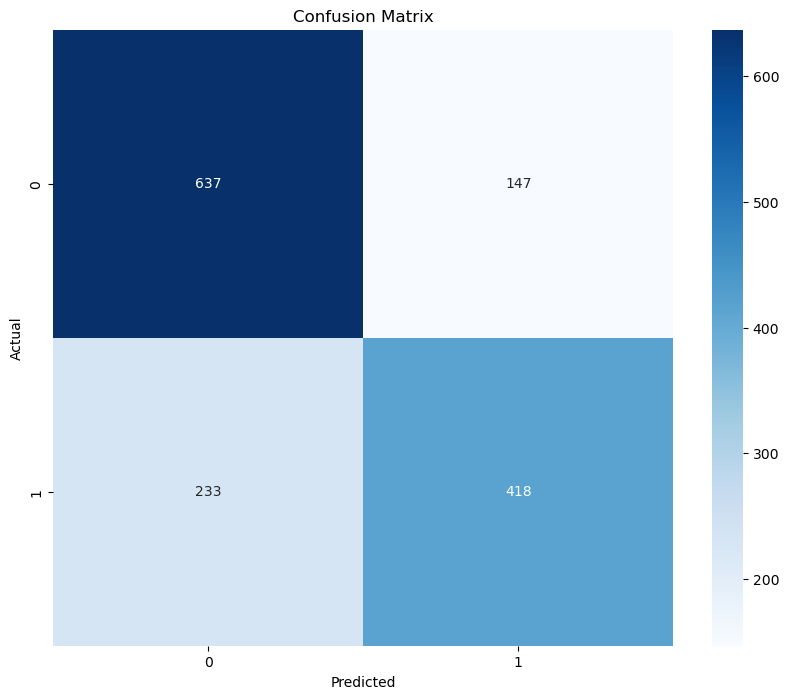

In [8]:
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare numerical data and classification target
X_num = X.drop(columns=['Sector'])
# Create a binary target: 1 if Target > Previous (Price Up), else 0
y_class = (df_model['Target'] > df_model['Previous']).astype(int)

imputer = SimpleImputer(strategy='median')

# Re-split the data
train_size = int(len(X_num) * 0.8)
X_train = X_num.iloc[:train_size]
X_test = X_num.iloc[train_size:]
y_train = y_class.iloc[:train_size]
y_test = y_class.iloc[train_size:]

# Impute missing values
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Define the classifier
model = RandomForestClassifier(random_state=42,class_weight='balanced')

# Fit the model
model.fit(X_train_imputed, y_train)

# Overfitting/Underfitting Check
train_score = model.score(X_train_imputed, y_train)
test_score = model.score(X_test_imputed, y_test)

print(f"Overfitting/Underfitting Check")
print(f"Training Accuracy: {train_score:.4f}")
print(f"Test Accuracy:     {test_score:.4f}")

# Classification Evaluation
y_pred = model.predict(X_test_imputed)
accuracy_score=accuracy_score(y_test,y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Balanced Accuracy Score: {balanced_acc:.4f}")
print(f"Classification Report: {report}")
print(f"Accuracy Score: {accuracy_score:.4f}")

# Plotting Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 2. Hyperparameter Tuning for Random Forest
To improve the baseline, we perform a grid search over key hyperparameters. We use `TimeSeriesSplit` to ensure the cross-validation respects the temporal nature of stock data, preventing look-ahead bias.

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.7808
Optimized Model Results
Optimized Training Accuracy: 0.7826
Optimized Test Accuracy:     0.7512
Classification Report               precision    recall  f1-score   support

           0       0.76      0.80      0.78       784
           1       0.74      0.70      0.72       651

    accuracy                           0.75      1435
   macro avg       0.75      0.75      0.75      1435
weighted avg       0.75      0.75      0.75      1435

Balance Accuracy Score 0.7465232060566163
Accuracy Score 0.7512


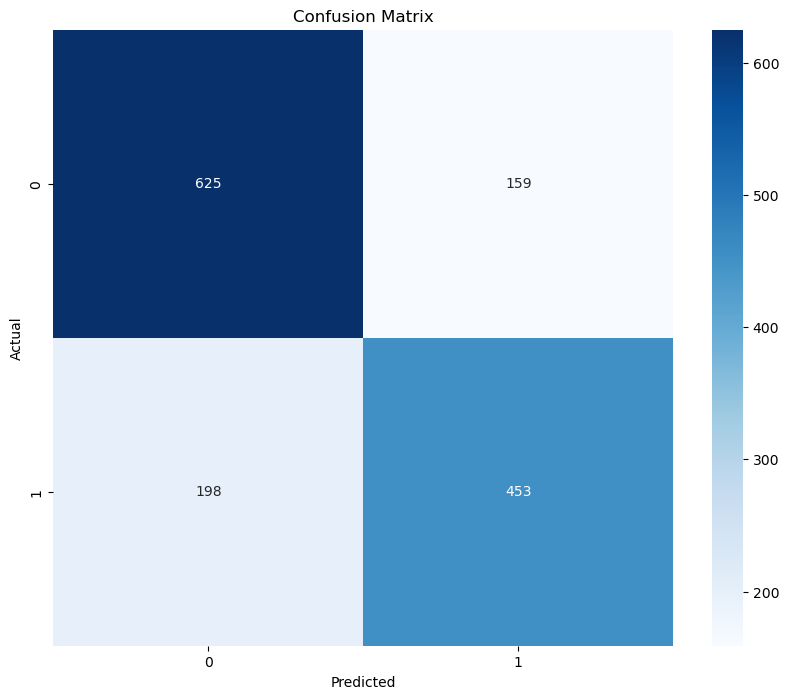

In [9]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score
# Define the parameter grid to explore
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt', 'log2']
}

# Setup TimeSeriesSplit which is crucial for financial data to prevent look ahead bias
tscv = TimeSeriesSplit(n_splits=5)

# Initialize the Classifier
model_tune = RandomForestClassifier(random_state=42, class_weight='balanced')

# Perform GridSearchCV
grid_search = GridSearchCV(
    estimator=model_tune,
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_imputed, y_train)

# Best results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# Evaluate the optimized model on the test set
best_model = grid_search.best_estimator_
test_tune_score = best_model.score(X_test_imputed, y_test)
train_tune_score = best_model.score(X_train_imputed, y_train)

print(f"Optimized Model Results")
print(f"Optimized Training Accuracy: {train_tune_score:.4f}")
print(f"Optimized Test Accuracy:     {test_tune_score:.4f}")

# Classification Report for the best model
y_pred_tune = best_model.predict(X_test_imputed)
print(f"Classification Report {classification_report(y_test, y_pred_tune)}")
print(f"Balance Accuracy Score {balanced_accuracy_score(y_test,y_pred_tune)}")
print(f"Accuracy Score {accuracy_score(y_test,y_pred_tune):.4f}")
cm_tune=confusion_matrix(y_test,y_pred_tune)
# Plotting Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_tune, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 3. XGBoost Implementation
We implement the XGBoost classifier, a powerful gradient boosting algorithm. A simplified grid search is performed to optimize its learning rate and depth, aiming for better generalization and predictive accuracy.

In [10]:
!pip install xgboost

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
XGBoost Performance
Training Accuracy: 0.7824
Test Accuracy:     0.7505
Classification Report               precision    recall  f1-score   support

           0       0.76      0.80      0.78       784
           1       0.74      0.70      0.72       651

    accuracy                           0.75      1435
   macro avg       0.75      0.75      0.75      1435
weighted avg       0.75      0.75      0.75      1435

Balance Accuracy Score 0.7458854509545754
Accuracy Score 0.7505226480836237


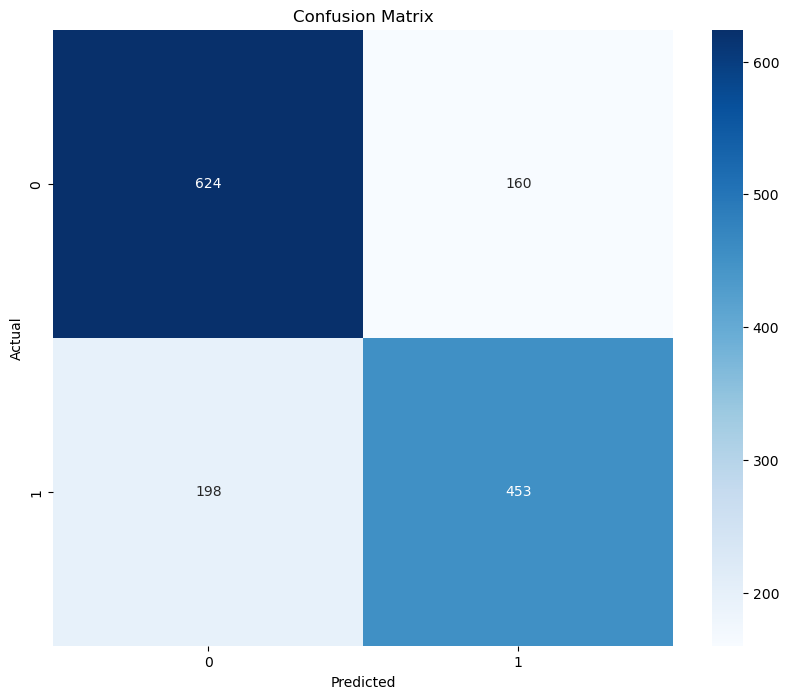

In [11]:
import xgboost as xgb
# Setup XGBoost with basic parameters
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)

# Simplified Parameter Grid
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8]
}

# Grid Search with TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
grid_search = GridSearchCV(xgb_model, param_grid, cv=tscv, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_imputed, y_train)

# Evaluation
best_xgb = grid_search.best_estimator_
test_xgb = best_xgb.score(X_test_imputed, y_test)
train_xgb = best_xgb.score(X_train_imputed, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"XGBoost Performance")
print(f"Training Accuracy: {train_xgb:.4f}")
print(f"Test Accuracy:     {test_xgb:.4f}")
# Predict
y_pred_xgb=best_xgb.predict(X_test_imputed)
print(f"Classification Report {classification_report(y_test, y_pred_xgb)}")
print(f"Balance Accuracy Score {balanced_accuracy_score(y_test, y_pred_xgb)}")
print(f"Accuracy Score {accuracy_score(y_test, y_pred_xgb)}")
cm_tune_xgb=confusion_matrix(y_test,y_pred_xgb)
# Plotting Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_tune_xgb, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 4. Final Model Evaluation
Here we evaluate the optimized XGBoost model. We plot the ROC Curve and calculate the AUC score to assess classification performance across thresholds, and visualize feature importance to understand what drives the model's decisions.

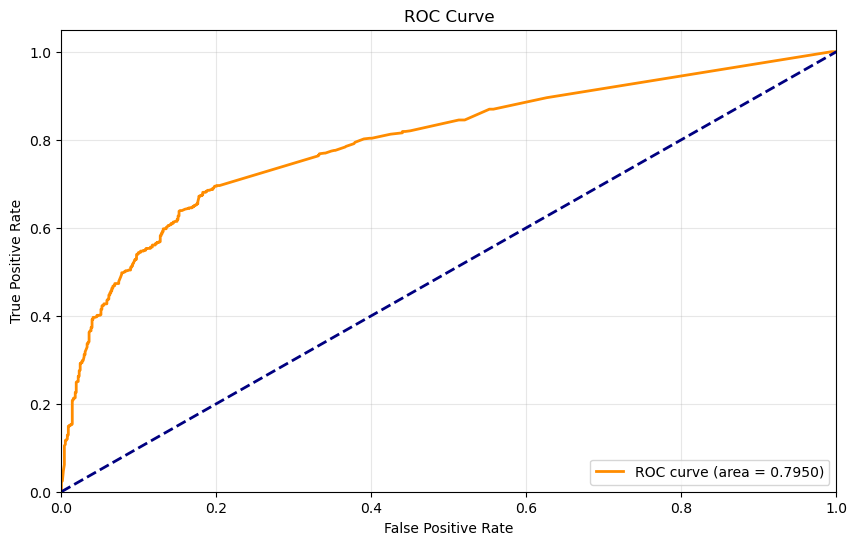

ROC AUC Score: 0.7950


In [12]:
from sklearn.metrics import roc_curve, roc_auc_score, auc

# ROC Curve and AUC Score
y_probs = best_xgb.predict_proba(X_test_imputed)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

/tmp/ipykernel_20956/3265980830.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


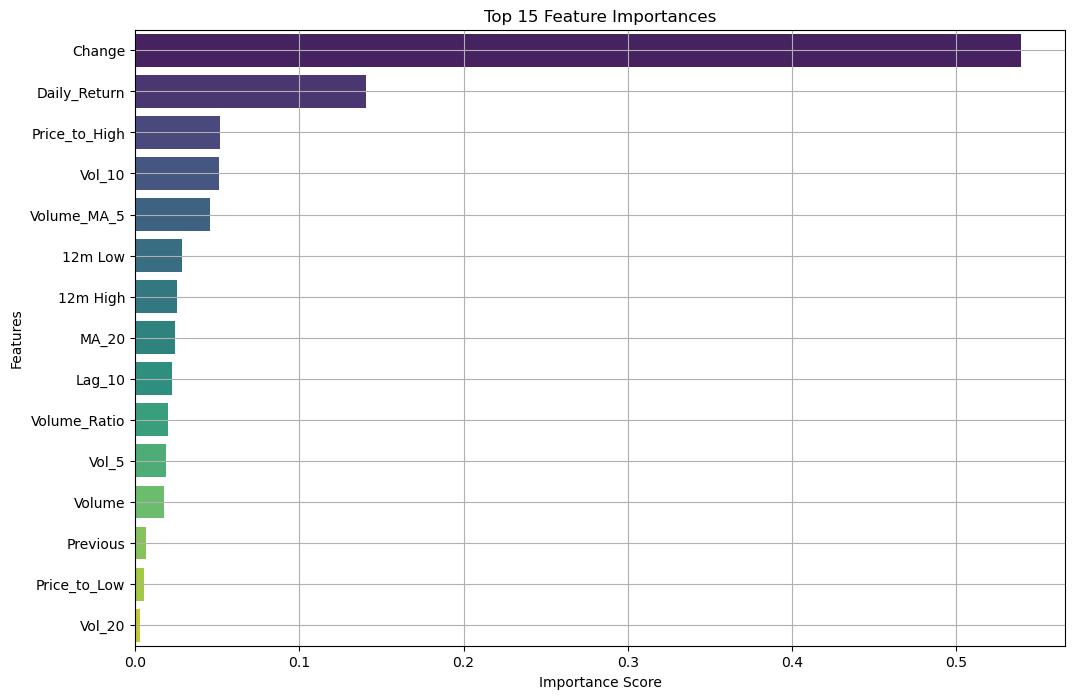

In [13]:
# Feature Importance
importances = best_xgb.feature_importances_
feature_names = X_num.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(True)
plt.show()


In [14]:
# Listing all unique institution names available in the dataset
institutions = df['Name'].unique().tolist()
print("List of Institutions:")
for name in sorted(institutions):
    print(f"- {name}")

List of Institutions:
- ABSA Bank Kenya Plc
- ABSA NewGold ETF
- Africa Logistics Properties Industria...
- Africa Mega Agricorp Plc
- BK Group Plc
- BOC Kenya Plc
- Britam Holdings Plc
- British American Tobacco Kenya Plc
- CIC Insurance Group Ltd
- Car and General (K) Ltd
- Carbacid Investments Plc
- Centum Investment Company Plc
- Co-operative Bank of Kenya Ltd
- Crown Paints Kenya Plc
- Diamond Trust Bank Kenya Ltd
- Eaagads Ltd
- East African Breweries Ltd
- East African Portland Cement Ltd
- Equity Group Holdings Plc
- Eveready East Africa Ltd
- Express Kenya Plc
- Family Bank Limited
- Flame Tree Group Holdings Ltd
- HF Group Ltd
- HFCB Group Plc
- Home Afrika Ltd
- I & M Holdings Plc
- Jubilee Holdings Ltd
- KCB Group Plc
- Kakuzi Plc
- Kapchorua Tea Kenya Plc
- Kenya Airways Plc
- Kenya Electricity Generating Company Plc
- Kenya Pipeline Company Plc
- Kenya Power and Lighting Company Plc
- Kenya Re-Insurance Corporation Ltd
- Kurwitu Ventures Ltd
- LAPTrust Imara Income-REIT
-

In [15]:
def predict_stock_movement(institution_name):
    # Find the latest data for the specific institution
    stock_data = df_model[df_model['Name'].str.contains(institution_name, case=False, na=False)]

    if stock_data.empty:
        return f"No data found for institution: {institution_name}"

    # Get the most recent record
    latest_record = stock_data.sort_values('Date').iloc[-1:]
    
    # Capture the numerical change to differentiate down vs stay
    actual_change = latest_record['Change'].values[0]

    # Prepare features
    X_input = latest_record.drop(columns=columns_to_drop)
    if 'Sector' in X_input.columns:
        X_input = X_input.drop(columns=['Sector'])

    # 3. Impute
    X_input_imputed = imputer.transform(X_input)

    # 4. Predict
    prediction = best_xgb.predict(X_input_imputed)[0]
    probability = best_xgb.predict_proba(X_input_imputed)[0]

    # Logic for if it goes UP,DOWN or STAYS the same
    if prediction == 1:
        result = "UP"
    else:
        if actual_change < 0:
            result = "DOWN"
        else:
            result = "STAYS THE SAME"

    confidence = probability[1] if prediction == 1 else probability[0]

    print(f"Prediction for {latest_record['Name'].values[0]}")
    print(f"Latest Date in Records: {latest_record['Date'].values[0]}")
    print(f"Predicted Movement: {result}")
    print(f"Model Confidence in Trend: {confidence:.2%}")

# Input name
institution = input("Name of the institution")
predict_stock_movement(institution)

Prediction for Safaricom Plc
Latest Date in Records: 2026-06-29T00:00:00.000000000
Predicted Movement: UP
Model Confidence in Trend: 68.88%


## Interactive Investment Analysis 


1.  *Data Analysis* The system will fetch the most recent technical indicators for your chosen institution.
2.  *Trend Forecasting* The XGBoost model will calculate the probability of the stock price moving UP based on current patterns.
3.  *Confidence Assessment* This probability will be shown as a 'Model Confidence' percentage, indicating the strength of the signal.
4.  *Investment Guidance* You will receive a recommendation based on confidence levels:
    *   *Strong*: High probability >70% of an upward trend.
    *   *Moderate*: Potential for growth 50% - 70%.
    *   *Weak*: Likely to remain stagnant or decrease <50%.
5.  *Performance Context:* The tool will provide the Average Daily Return to help you compare the model's signal with historical performance.

In [16]:
def evaluate_specific_investment(institution_name, df_model, model, imputer, columns_to_drop):
    # Filter data for the specific institution
    stock_history = df_model[df_model['Name'].str.contains(institution_name, case=False, na=False)]

    if stock_history.empty:
        print(f"No data found for institution: '{institution_name}'")
        return

    # Get the latest record for prediction
    latest_record = stock_history.sort_values('Date').iloc[-1:]
    
    # Calculate Average daily return from history
    avg_return = stock_history['Daily_Return'].mean()

    # Prepare features for the model
    X_input = latest_record.drop(columns=columns_to_drop)
    if 'Sector' in X_input.columns:
        X_input = X_input.drop(columns=['Sector'])

    # Predict and get probability
    X_input_imputed = imputer.transform(X_input)
    prob_up = model.predict_proba(X_input_imputed)[0][1]

    # Determine recommendation strength
    if prob_up >= 0.70:
        recommendation = "Strong"
    elif prob_up >= 0.50:
        recommendation = "Moderate"
    else:
        recommendation = "Weak,Price likely to stay same or drop"

    # Output Results
    print(f"\nAnalysis for {latest_record['Name'].values[0]}")
    print(f"Sector {latest_record['Sector'].values[0]}")
    print(f"Model Confidence: {prob_up:.2%}")
    print(f"Recommendation {recommendation}")
    print(f"Average Daily Return {avg_return:.4%}")

# User input interaction
user_input = input("Name of the Institution: ")
evaluate_specific_investment(user_input, df_model, best_xgb, imputer, columns_to_drop)

No data found for institution: 'Safarcom PLC'
